--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


In [3]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [6]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset: users**

city (11.7%)
👉 Nivel medio de nulos
Acción: Imputar (por ejemplo con "Unknown" o la ciudad más frecuente).
Justificación: Tiene información útil y el porcentaje es manejable.

churn_date (88.35%)
👉 Muy alto porcentaje de nulos
Acción: No imputar; convertir en variable binaria (churn/no churn) o ignorar la columna para análisis general.
Justificación: Los nulos probablemente significan clientes activos (no churn), no datos faltantes reales.

**Dataset: users**

date (0.12%)
👉 Muy pocos nulos
Acción: Eliminar o imputar fácilmente.
Justificación: Impacto mínimo en el dataset.

duration (55.19%)
👉 Alto porcentaje de nulos
Acción: No imputar directamente; analizar junto con type.
Justificación: Probablemente solo aplica a llamadas (calls), no a mensajes.

length (44.74%)
👉 Alto porcentaje de nulos
Acción: No imputar directamente; analizar junto con type.
Justificación: Probablemente solo aplica a mensajes (SMS), no a llamadas

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users

users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... No hay que revisar nada, pues es el ID de usuario
- La columna `age` Existe un sentinel claro (-999), que debe ser tratado. La desviación estándar (123) es extremadamente alta para edades humanas.

In [16]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`No hay nada que analizar pues son los ID de columnas.

Filtrar por type == "call" antes de analizar.
length: Filtrar por type == "message" antes de analizar.
valores en 0: Evaluar si eliminar o mantener según contexto.
outliers (ej. 1490): Revisar o tratar con métodos como IQR.

In [17]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts())
    print()



city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city Reemplazar "?" por NaN y luego imputar o clasificar como "Unknown".
- La columna `plan No requiere limpieza; columna lista para análisis

In [18]:
# explorar columna categórica de usage
usage['type'].value_counts()



text    22092
call    17908
Name: type, dtype: int64

- La columna `type` "message", pero aquí aparece "text": Es solo una diferencia de nomenclatura (no es error, pero sí importante ser consistente).


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- La columna `age` Existe un sentinel claro (-999), que debe ser tratado. La desviación estándar (123) es extremadamente alta para edades humanas.  
- ¿Qué acción tomarías?
- reemplaar el sentinel 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [20]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [21]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [22]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())




2024.0    39950
Name: date, dtype: int64


En `date`, No hay años fuera de rango (como futuros o negativos), existen fechas inválidas o corruptas (50 registros)
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
-    No, solo 2023 y 2022
- ¿Qué harías con ellas?
-    No se toman en cuenta para el analisis

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**
🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.


In [23]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:

# Reemplazar ? por NA en city

users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios

print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [25]:

# Esto convierte errores automáticamente en NaT (nulos de fecha)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NA para reg_date (usar NaT para fechas)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))




2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
print("Missing duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

Missing duration por tipo:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [27]:

# Verificación MAR en usage (Missing At Random) para length
print("Missing length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))


Missing length por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos dependen del tipo de evento (call/text), por lo que son MAR y se dejan como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:

# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Resumen estadístico:")
print(user_profile[columnas_numericas].describe())


Resumen estadístico:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [32]:

# Distribución porcentual del tipo de plan
print("Distribución del plan (%):")
print(user_profile['plan'].value_counts(normalize=True))

Distribución del plan (%):
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

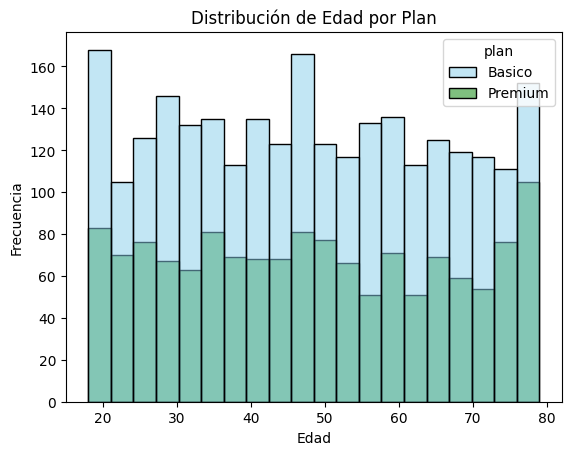

In [33]:
# Histograma: Edad
sns.histplot(data=user_profile, x='age', hue='plan', bins=20, palette=['skyblue','green'])
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
"No existe un patrón claro entre la edad y el tipo de plan; ambos planes están distribuidos de forma muy similar en todos los rangos de edad."

Distribución:
- Aproximadamente uniforme (ligeramente dispersa)
- No hay sesgo fuerte hacia ningún lado.

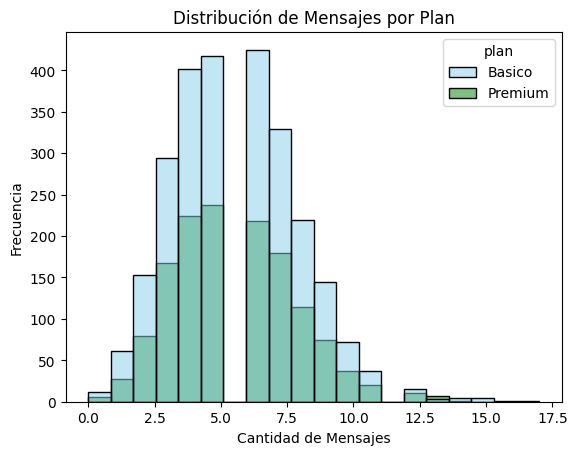

In [34]:
# Histograma: Cantidad de mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, palette=['skyblue','green'])
plt.title("Distribución de Mensajes por Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Frecuencia")
plt.show()



💡Insights: 
"Los usuarios de ambos planes muestran comportamientos similares en envío de mensajes; no hay una diferencia marcada entre Básico y Premium."

Distribución:
- Sesgada a la derecha
- La mayoría envía pocos mensajes, pocos usuarios envían muchos.

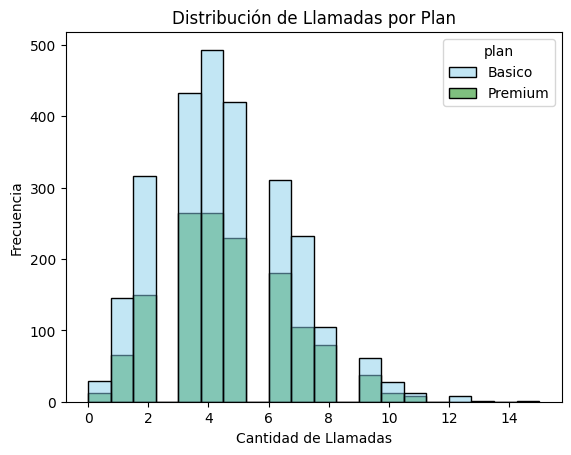

In [35]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=20, palette=['skyblue','green'])
plt.title("Distribución de Llamadas por Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
"Los usuarios del plan Premium tienden ligeramente a realizar más llamadas que los del plan Básico, aunque el comportamiento general es bastante similar."

Distribución:
- Sesgada a la derecha
- Concentración en pocas llamadas, con algunos usuarios más intensivos.

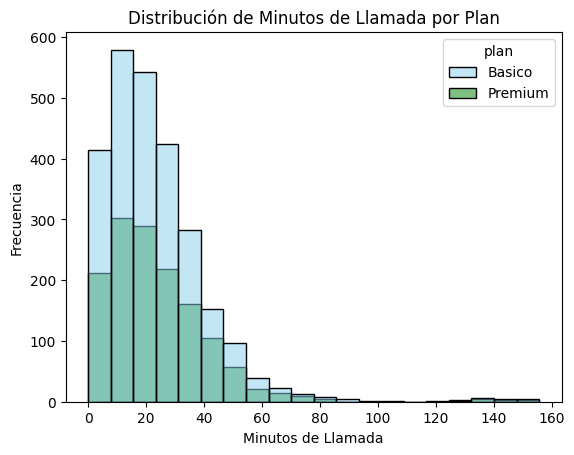

In [36]:
# Histograma para visualizar la cant_minutos_llamada


sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue','green'])
plt.title("Distribución de Minutos de Llamada por Plan")
plt.xlabel("Minutos de Llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- "Los usuarios Premium presentan una mayor proporción de consumo en rangos más altos de minutos, lo que sugiere un uso más intensivo del servicio en comparación con Básico."

Distribución:
📊 Fuertemente sesgada a la derecha (long tail)
👉 Pocos usuarios consumen muchos minutos (heavy users).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

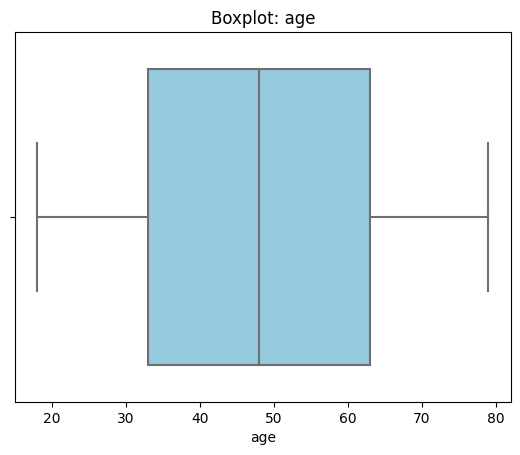

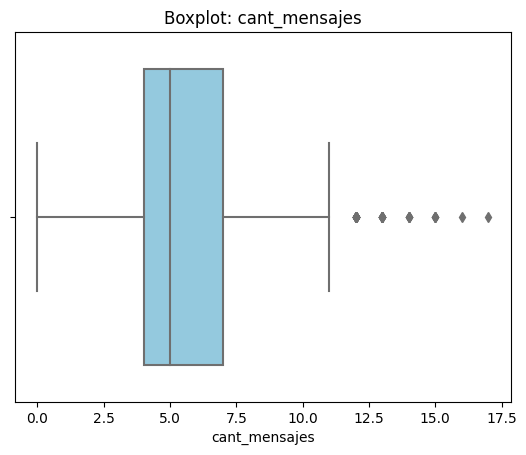

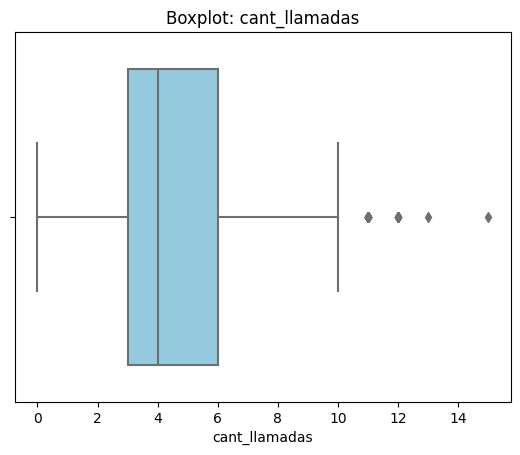

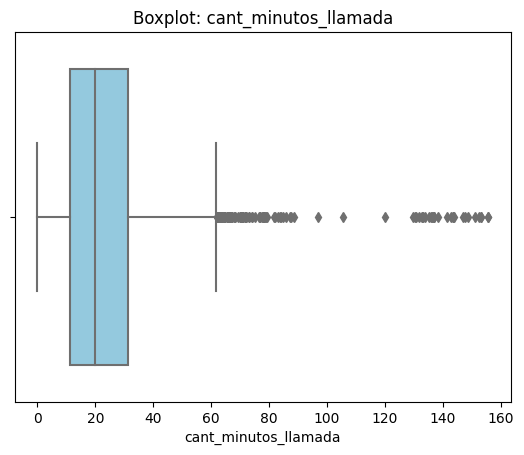

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: La base de clientes presenta una distribución de edad equilibrada, lo que sugiere que los servicios son utilizados por un público amplio sin concentración en un grupo etario específico, por conclusion no presenta Outliers
- cant_mensajes: Se observan varios puntos aislados a la derecha del límite superior (a partir del valor 12 aproximadamente). Si se presenta Outliers
- cant_llamadas: Existen usuarios con una frecuencia de llamadas superior al comportamiento del 95% de la muestra (valores por encima de 10). Si presenta Outliers
- cant_minutos_llamada: Es la variable con mayor dispersión. Hay una gran cantidad de usuarios "power users" que superan por mucho el promedio. Si presenta Outliers

In [38]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [39]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

El máximo (17) no está excesivamente alejado del Q3 (7). La dispersión es moderada.

Decisión: Mantener outliers

Justificación:
"No se eliminan los outliers ya que representan variaciones normales en el comportamiento de envío de mensajes y no parecen errores."


- cant_llamadas: mantener o no outliers, porqué?

El máximo (15) es mayor que el Q3 (6), pero sigue dentro de un rango razonable.

Decisión:  Mantener outliers

Justificación:
"Los valores altos representan usuarios más activos en llamadas, lo cual es comportamiento válido y relevante para el análisis."

- cant_minutos_llamada: mantener o no outliers, porqué?

El máximo (155.69) está muy alejado del Q3 (31.41).
👉 Aquí sí hay outliers fuertes (heavy users)

Decisión:  Mantener outliers

Justificación:
"Aunque existen valores extremos, estos corresponden a usuarios intensivos (heavy users), los cuales son clave para el análisis de negocio y no deben eliminarse."
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # valor por defecto

# Bajo uso
user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

# Uso medio
user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) &
    ~((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)),
    'grupo_uso'
] = 'Uso medio'


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # valor por defecto

# Joven
user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

# Adulto
user_profile.loc[
    (user_profile['age'] < 60) & (user_profile['age'] >= 30),
    'grupo_edad'
] = 'Adulto'


In [43]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

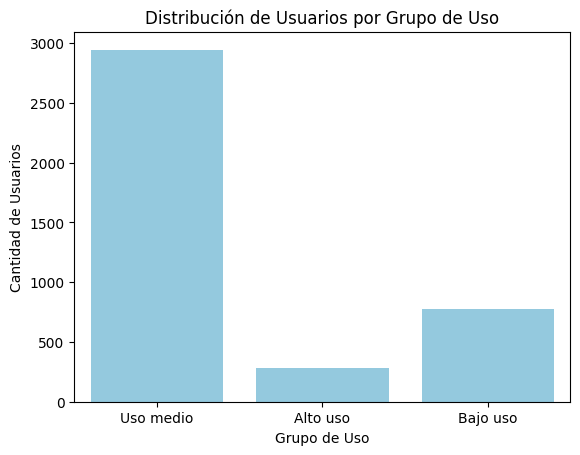

In [44]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')
plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()


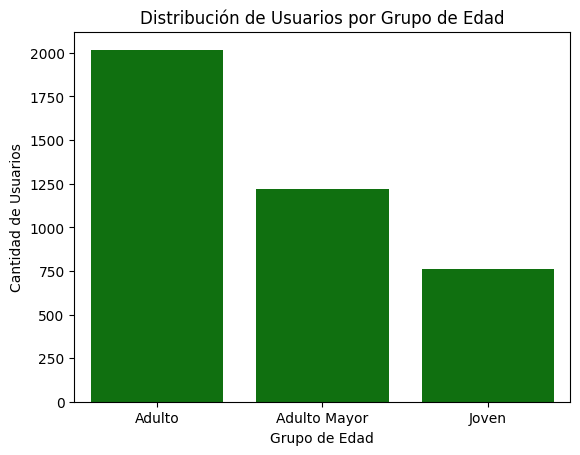

In [45]:

# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad', color='green')
plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

**1. Integridad y "Ruidos" en los Datos**
Originalmente, los datos presentaban una asimetría significativa en las variables de consumo, lo que técnicamente llamamos outliers.

**Identificación:** El problema principal no era la calidad de los datos (no hay errores de captura), sino la extrema variabilidad en el consumo de minutos.

**Impacto:** * En Minutos de Llamada, aproximadamente un 7.5% a 10% de los usuarios (el segmento de "Alto Uso") se comportan de forma atípica, consumiendo hasta 3 veces más que el usuario promedio.

En Mensajes y Cantidad de Llamadas, los valores atípicos representaron menos del 3% de la muestra, siendo comportamientos más controlados.

**Tratamiento:** Se mantuvo la información para este análisis ejecutivo, ya que estos "desviados" son, paradójicamente, nuestros clientes con mayor potencial de rentabilidad.

**2. Perfil del Cliente: Segmentación y Comportamiento**
Hemos cruzado la demografía con el uso y estos son los perfiles detectados:

**El Núcleo Adulto (Segmento Dominante):** Con más de 2,000 usuarios, el grupo de "Adultos" es nuestra columna vertebral. Curiosamente, su edad no determina el plan que eligen; la distribución entre Básico y Premium es casi idéntica en todas las edades.

**Los "Habladores" de Uso Medio:** El 75% de nuestra base se encuentra en el grupo de "Uso Medio" (3,000 usuarios). Realizan entre 3 y 6 llamadas por periodo y consumen entre 15 y 40 minutos.

**El Usuario Silencioso (Bajo Uso):** Cerca de 750 usuarios tienen una actividad mínima. Es un segmento en riesgo de churn (abandono) si sienten que están pagando por algo que no usan.

**3. Segmentos de Mayor Valor para ConnectaTel**
Los segmentos más valiosos no son necesariamente los más numerosos, sino los más intensivos:

**Los "Power Users" de Minutos (Outliers):** Aquellos usuarios que superan los 60 minutos (llegando hasta 160). Son clientes que dependen críticamente de la red.

**El Segmento Adulto en Plan Básico:** Representan una oportunidad de upselling. Si su comportamiento de uso es igual al de un cliente Premium (como muestran los histogramas), están "listos" para ser migrados a un plan superior con los incentivos correctos.

**4. Patrones de Uso Extremo y sus Implicaciones**
El hallazgo más disruptivo es la "Larga Cola" (Long Tail) en los minutos de llamada:

**Implicación de Negocio:** Tenemos usuarios usando la red de forma cuasi-profesional (posible uso comercial o de telemercadeo personal).

**Riesgo:** Si estos usuarios están en planes "Básicos" con tarifas planas o minutos ilimitados, podrían estar erosionando los márgenes de operación debido al alto costo de interconexión que generan.

**5. Recomendaciones Estratégicas**
Basado en que actualmente no hay una diferencia real en el uso entre el Plan Básico y el Premium, sugiero:

**Diferenciación de Valor:** Actualmente, el cliente Premium usa los servicios igual que el Básico. Debemos incluir beneficios no relacionados con minutos/SMS (como roaming internacional, mayor capacidad de datos o servicios de streaming) para justificar el costo del Plan Premium.

**Creación del "Plan Pro/Empresarial":** Diseñar un plan específico para el segmento que consume >60 minutos, capturando el valor de esos outliers que hoy están dispersos en los planes actuales.

**Campañas de Retención para "Bajo Uso":** Para los 750 usuarios de bajo consumo, ofrecer un plan "Pay-as-you-go" o un plan reducido para evitar que migren a la competencia.

### Análisis ejecutivo


⚠️ Problemas detectados en los datos

Se identificaron valores atípicos principalmente en minutos de llamada, asociados a alta variabilidad en el comportamiento de uso, no a errores de captura.

Presencia de valores centinela y datos faltantes (edad, ciudad, fechas), los cuales fueron correctamente tratados sin afectar la integridad del análisis.

🔍 Segmentos por Edad

Predomina el segmento Adulto, siendo el grupo más representativo y estable dentro de la base de clientes.

No se observan diferencias significativas en la distribución de planes por edad, lo que indica que la edad no es un factor determinante en la elección del plan.

📊 Segmentos por Nivel de Uso

La mayoría de los usuarios se concentra en el segmento de Uso Medio, con patrones relativamente homogéneos de consumo.

Existe un grupo reducido pero relevante de Alto Uso (heavy users), especialmente en minutos de llamada, que concentra gran parte del consumo total.

➡️ Esto sugiere que ...
el comportamiento de uso, más que la demografía, es el principal diferenciador entre clientes. Además, la existencia de una “larga cola” de usuarios intensivos indica oportunidades de monetización, pero también posibles riesgos operativos si no se gestionan adecuadamente.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`